<h1 style="text-align:center;">Market impact modelling : Offline Learning Approach to Propagator Models</h1>

Source : [Offline learning Approach to Propagator Models](https://arxiv.org/abs/2309.02994)

## Sumary :

* [**1.Theory and principal results**](#0)
* [**2.Scenarios generator**](#1)
* [**3.Calibration of the propagator G**](#2)
    * [3.1. Estimator unconstrained $\tilde G_{N,\lambda}$](#2_1)
    * [3.2. Projection in $G_{ad}$](#2_1)

* [**4.Optimal liquidation strategies**](#3)
    * [4.1. Optimal and greedy strategy](#3_1)
    * [4.2. Pessimistic optimal strategy](#3_2)
    * [4.3. Presentation of results](#3_3)


    

<a id='0'></a>
# 1. Theory and principal results :


## Propagator Model

We consider a discrete trading horizon $0 = t_1 < t_2 < \dots < t_M = T$ and an execution strategy described by the traded quantities $u = (u_{t_1}, \dots, u_{t_M}).$

The propagator model assumes the existence of a **lower-triangular matrix**

$$
G = (G_{i,j})_{1\le j \le i \le M}
$$

called the *propagator* or *price impact kernel*, such that the execution price satisfies (we remove trading signal $A$ considered in the paper)

$$
S_{t_{i+1}}
=
S_{t_1}
+
\sum_{j=1}^{i} G_{i,j} u_{t_j}
+
\varepsilon_{t_i}.
$$

Here

- $\varepsilon_{t_i}$ is a noise term,
- the term $\sum_{j\le i} G_{i,j}u_{t_j}$ captures **transient market impact**.

A trade executed at time $t_j$ continues to affect future prices, with a typically decreasing influence as $i-j$ increases.

---

### Fundamental Properties

- #### Lower-triangular :

The lower-triangular structure of $G$ reflects **causality**, only past trades can influence the current price : 

$$G_{i,j} = 0 \quad \text{for } j>i$$

- #### Convolution Case :

We also assume that we have **time-invariance** of the propagator, meaning that impact depends only on the time lag (stationnarity) : $G_{i,j} = K(i-j), \quad i \ge j$

In this case cause the matrix $G$ to have a **Toeplitz triangular structure**

$$
G =
\begin{pmatrix}
K_0 & 0 & 0 & \cdots & 0 \\
K_1 & K_0 & 0 & \cdots & 0 \\
K_2 & K_1 & K_0 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & 0 \\
K_{M-1} & K_{M-2} & K_{M-3} & \cdots & K_0
\end{pmatrix}.
$$

The propagator is therefore fully determined by the kernel $K = (K_0, K_1, \dots, K_{M-1}).$

The price dynamics can be written as a discrete convolution : $(K * u)_i = \sum_{j \le i} K(i-j) u_j.$

In the convolution case, we have only $M$ parameters to estimate (contrary to the general Volterra case with $\frac{M(M+1)}{2}$ parameter), the paper show that this assumption increase the rate of convergence.

- #### AOA $\iff$ Linear Market Impact :

From a theoretical perspective, the absence of dynamic arbitrage (AOA) imposes a **linear structure of market impact with respect to the trading rate**, which justifies the linear form of the term

$$
\sum_{j=1}^{i} G_{i,j} u_{t_j}
$$

in propagator models. See [No-Dynamic-Arbitrage and Market Impact](https://doi.org/10.1080/14697680903373692).

---

### Offline Learning Framework

We consider the problem of optimal liquidation in a market where trading generates price impact. The main difficulty is that the impact function, represented by the propagator $G^{*}$, is **unknown** and must be estimated from historical data.

We assume access to a dataset of observed trading episodes

$$
D = \{(S^{(n)}, u^{(n)})\}_{n=1}^{N}
$$

where each triple corresponds to

- a price trajectory
- an executed trading strategy

This setting corresponds to the **offline learning paradigm** : fixed dataset without additional interaction with the environment.

The objective is therefore to use the observations in $D$ to estimate the propagator $G^{*}$ and subsequently derive an optimal liquidation strategy.

---

### Cost Function

Let $u = (u_{t_1}, \dots, u_{t_M})$ denote a trading strategy. The total execution cost is defined as

$$
C(u) = \sum_{i=1}^{M} u_{t_i}(S_{t_{i+1}} - S_{t_1}).
$$

Substituting the propagator dynamics yields

$$
C(u) =
\sum_{i=1}^{M}
u_{t_i}
\left(
\sum_{j \le i} G_{i,j}u_{t_j}
+
\varepsilon_{t_i}
\right)
$$

This explain the following form of the cost function : 


$$
\boxed{
J(u;G)
=
E[C(u)]
=
\sum_{i=1}^{M}
\sum_{j=1}^{i}
G_{i,j} u_j u_i
}
$$

In [151]:
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
from dataclasses import dataclass, field
from typing import Tuple
import cvxpy as cp

<a id='1'></a>
# 2. Scenario Generator

The objective of this part is to create an artificial dataset $D = \{(S^{(n)}, u^{(n)})\}_{n=1}^{N}$ using a given propagator matrix $G$ (which is not observed by the agent for the rest of the project).

We consider a **convolutional propagator**  $G_{i,j} = K(i-j)$ and we assume an **exponential kernel** of the form :

$$
K(t) = k e^{-\rho t}, \qquad t \ge 0,
$$

where $k>0$ represents the instantaneous impact and $\rho>0$ controls the decay of market impact.

The propagator matrix therefore takes the form

$$
G =
\begin{pmatrix}
K_0 & 0 & 0 & \cdots & 0 \\
K_1 & K_0 & 0 & \cdots & 0 \\
K_2 & K_1 & K_0 & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & 0 \\
K_{M-1} & K_{M-2} & K_{M-3} & \cdots & K_0
\end{pmatrix}.
$$

Using this kernel, the price dynamics are simulated according to

$$
S_{t_{i+1}}
=
S_{t_1}
+
\sum_{j=1}^{i} G_{i,j} u_{t_j}
+
\varepsilon_{t_i},
$$

where $(\varepsilon_{t_i})$ is a noise term representing exogenous price fluctuations.

---

### Price generation model

Given a trading trajectory $u = (u_0,\dots,u_{N-1})$ and a propagator matrix $G$,
the price trajectory $S = (S_0,\dots,S_{N-1})$ is generated according to

$$
S = S_0 + u G^\top + \varepsilon
$$

where

- $S_0$ is the initial price level,
- $G$ is the propagator matrix defined by the kernel,
- $u$ is the trading rate trajectory,
- $\varepsilon \sim \mathcal{N}(0,\sigma^2 I)$ is a Gaussian noise vector.

In [152]:
def G_exponential_kernel(N : int, k : float, rho : float):
    """
    Give G matrix according exponential kernel

    Inputs
    ------
    N   : Size of the matrix
    g0  : first parameter of exp kernel
    rho : second parameter of exp kernel

    Outputs
    -------
    G matrix
    """

    # G matrix
    G = np.zeros((N, N))
    
    for i in range(N):
        for j in range(i + 1):
            G[i, j] = k * np.exp(-rho * (i - j))

    return G


def generator(n: int, N: int, seed: int, k: float, rho: float, sigma: float,
              u_sigma: float = 1.0, S0: float = 0.0):
    """
    Generate an artificial dataset D = {(S^(k), u^(k))}_{k=1}^n using
    an exponential convolution kernel encoded in a lower-triangular matrix G.

    Model (discrete time i=0,...,N-1)
    --------------------------------
    u^(k)_i ~ N(0, u_sigma^2)   i.i.d.
    eps^(k)_i ~ N(0, sigma^2)   i.i.d., independent of u
    S^(k) = S0 + G u^(k) + eps^(k)

    Inputs
    ------
    n      : number of trajectories (samples)
    N      : number of time steps (length of each trajectory)
    g0     : first parameter of exp kernel
    rho    : second parameter of exp kernel
    sigma  : standard deviation of noise epsilon
    u_sigma: standard deviation of trading rates u (default 1.0)
    S0     : initial price level (default 0.0)
    seed   : random seed (default None)

    Outputs
    -------
    S : numpy array of shape (n, N) containing price trajectories
    u : numpy array of shape (n, N) containing trading rates
    G : numpy array of shape (N, N) the propagator matrix used
    """

    rng = np.random.default_rng(seed)

    # Build G once
    G = G_exponential_kernel(N, k, rho)

    # Sample trading rates u and noise
    u = rng.normal(loc=0.0, scale=u_sigma, size=(n, N))
    eps = rng.normal(loc=0.0, scale=sigma, size=(n, N))

    # Prices: S = S0 + u @ G.T + eps  (because (G u)_i = sum_j G_{i,j} u_j)
    S = np.zeros((n, N + 1))
    S[:, 0] = S0
    S[:, 1:] = S0 + u @ G.T + eps

    return S, u, G

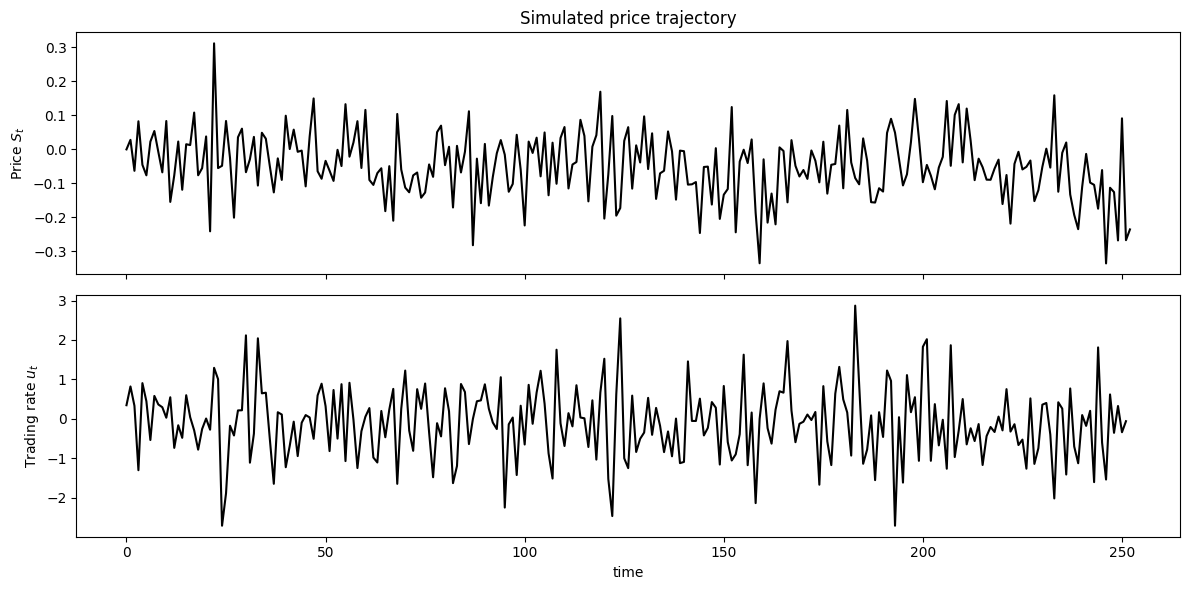

In [153]:
# --- parameters (same in the paper) ---
n = 1
N = 252
k = 0.01
rho = 0.01
sigma = 0.1
seed = 1

# --- simulate dataset ---
S, u, G = generator(n, N, seed, k, rho, sigma)

S = S[0]
u = u[0]

# --- plot ---
fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

ax[0].plot(S, color ='black')
ax[0].set_ylabel("Price $S_t$")
ax[0].set_title("Simulated price trajectory")

ax[1].plot(u, color ='black')
ax[1].set_ylabel("Trading rate $u_t$")
ax[1].set_xlabel("time")

plt.tight_layout()
plt.show()

<a id='2'></a>
# 3. Calibration of the estimator G

**Methodology:** we first compute the unconstrained regularized least-squares estimator 
$\tilde G_{N,\lambda} \in \mathbb{R}^{M \times M}$, and then project it into the admissible set 
of propagators $G_{ad}$.

We recall that the data used is of the form : $D = \{(S)^n, (u)^n\}_{n=1}^N$

---
<a id='2_1'></a>
### 3.1 Estimator unconstrained $\tilde G_{N,\lambda}$

We consider the regularized unconstrained estimator $\tilde G_{N,\lambda}$:

$$
\boxed{
\tilde G_{N,\lambda}
=
\arg\min_{G\in\mathbb{R}^{M\times M}}
\left(
\sum_{n=1}^{N}
\|y^{(n)}-Gu^{(n)}\|^2
+
\lambda\|G\|^2_{\mathbb{R}^{M\times M}}
\right)
}
$$

where $\|G\|^2_{\mathbb{R}^{M\times M}} =\mathrm{Tr}(G^\top G)$ is the Frobenius norm and :

- $y^{(n)} \in \mathbb{R}^M$ $\space$ ($y_i^{(n)}= S^{(n)}_{t_{i+1}} - S^{(n)}_{t_1}$)
- $u^{(n)} \in \mathbb{R}^M$
- $G \in \mathbb{R}^{M\times M}$


--- 

#### Close form of the estimator

We define the objective function as : $L(G)=\sum_{n=1}^{N}\|y^{(n)}-Gu^{(n)}\|^2+\lambda \mathrm{Tr}(G^\top G)$



Expanding the quadratic term gives

$$
L(G)
=
\sum_{n=1}^{N}
(y^{(n)}-Gu^{(n)})^\top (y^{(n)}-Gu^{(n)})
+
\lambda \mathrm{Tr}(G^\top G)
=
\sum_{n=1}^{N}
\Big(
(y^{(n)})^\top y^{(n)}
-
2 (y^{(n)})^\top G u^{(n)}
+
(u^{(n)})^\top G^\top G u^{(n)}
\Big)
+
\lambda \mathrm{Tr}(G^\top G).
$$

$L$ is stricly convex as soon as $\lambda \geq 0$, we can take the derivative with respect to $G$ :

$$
\nabla_G L(G)
=
\sum_{n=1}^{N}
\Big(
-2y^{(n)}(u^{(n)})^\top
+
2G u^{(n)}(u^{(n)})^\top
\Big)
+
2\lambda G .
$$

So we have

$$
\nabla_G L(G) = 0 \implies
\sum_{n=1}^{N} y^{(n)}(u^{(n)})^\top
=
G
\left(
\sum_{n=1}^{N} u^{(n)}(u^{(n)})^\top
+
\lambda I
\right).
$$


$$
\implies
\boxed{
\tilde G_{N,\lambda}
=
\left(
\sum_{n=1}^{N} y^{(n)}(u^{(n)})^\top
\right)
\left(
\sum_{n=1}^{N} u^{(n)}(u^{(n)})^\top
+
\lambda I
\right)^{-1}
}
$$

---

In [154]:
def G_estimator_unconstrainded(S: list, u: list, Lambda: float):
    """
    Return the G estimator on the M^{N*N} set (unconstrainded)

    Inputs
    ------
    S   : matrix (N x (M+1)) of trajectories
    u   : matrix (N x M) of orders

    Outputs
    -------
    G_{N, Lambda} : unconstrained estimator
    """

    # Array type
    S = np.array(S, dtype=float)
    u = np.array(u, dtype=float)

    # Sizes
    N, M = u.shape

    # Identity matrix
    Id = np.eye(M)

    # Build Y matrix
    # y^(n) = (S_{t_{i+1}} - S_{t_1})
    Y = S[:, 1:] - S[:, [0]]

    # Closed form ridge estimator
    A = Y.T @ u
    B = u.T @ u + Lambda * Id

    G_estimator = A @ np.linalg.inv(B)

    return G_estimator

---
<a id='2_2'></a>
### 3.2 Projection in $G_{ad}$ :


The propagator matrix must belong to the set $G_{ad}.$

This set contains matrices satisfying three economic and structural constraints.

- **Lower triangular structure :** $G_{i,j} = 0 \quad \text{for } i < j$



- **Positivity :** $G_{i,j} \ge 0$

This ensures that trades move prices in the expected direction (buy $\implies$ price up, sell $\implies$ price down):



- **Coercivity :** $x^\top (G + G^\top) x \ge \kappa \|x\|^2$ with ($\kappa > 0$)

This condition guarantees that the optimal execution problem is **well posed and convex**.

- **Convolutional :** : $G_{i,j} = K_{i - j}$ 

This condition permite tu reduce the number of parameters et accelerate dthe convergence of the optimization.

---

#### Definition of the constrained estimator :

The final estimator is defined as

$$
\boxed{
G_{N,\lambda}
=
\arg\min_{G \in G_{ad}}
\left\|
(G - \tilde G_{N,\lambda}) V_{N,\lambda}^{1/2}
\right\|_F^2}
$$

where

$$
V_{N,\lambda}
=
\sum_{n=1}^{N} u^{(n)} (u^{(n)})^\top
+
\lambda I.
$$

This corresponds to a **weighted projection** of the unconstrained estimator onto the admissible set.

Intuitively, we look for the admissible matrix $G$ that is **closest to the ridge estimator**.

---

In [155]:
def G_estimator_constrainded(G_tilde: list, u: list, Lambda: float, kappa: float = 0.0):
    """
    Return the G estimator on the G_{admissible} set (constrainded)
    in the convolutional case.

    Inputs
    ------
    G_tilde : matrix (M x M)  (unconstrained estimator)
    u       : matrix (N x M) of orders
    Lambda  : regularization parameter
    kappa   : coercivity parameter

    Outputs
    -------
    G_{N, Lambda} : constrained estimator
    """

    # Array type
    G_tilde = np.array(G_tilde, dtype=float)
    u = np.array(u, dtype=float)

    # Sizes
    N, M = u.shape

    Id = np.eye(M)                     # Identity matrix
    B = u.T @ u + Lambda * Id          # Build V_{N,Lambda}
    sqrt_B = np.linalg.cholesky(B).T   # Factor for weighted Frobenius norm

    # Convolution parameters
    params = cp.Variable(M)

    # Build convolutional lower-triangular matrix G
    G = cp.bmat([
        [params[i - j] if i >= j else 0 for j in range(M)]
        for i in range(M)
    ])

    # Objective
    objective = cp.Minimize(cp.sum_squares((G - G_tilde) @ sqrt_B))

    # Constraints
    constraints = []

    # Positivity
    constraints.append(params >= 0)

    # Monotonicity: K_{i+1} <= K_i
    for i in range(M - 1):
        constraints.append(params[i + 1] <= params[i])

    # Discrete convexity:
    # K_i - K_{i-1} <= K_{i+1} - K_i
    for i in range(1, M - 1):
        constraints.append(params[i] - params[i - 1] <= params[i + 1] - params[i])

    # Optional coercivity
    # In the convolutional lower-triangular case, positivity of params
    if kappa > 0:
        constraints.append(G + G.T - kappa * Id >> 0)

    # Problem
    problem = cp.Problem(objective, constraints)

    # Solver
    problem.solve(solver=cp.SCS, verbose=False)

    if params.value is None:
        raise ValueError("Optimization failed: no solution returned by CVXPY.")

    G_value = np.zeros((M, M))
    params_value = np.array(params.value).reshape(-1)

    for i in range(M):
        for j in range(i + 1):
            G_value[i, j] = params_value[i - j]

    return G_value

In [156]:
#----- Application ------
# --- parameters (same in the paper) ---
n = 100
N = 52
k = 0.01
rho = 0.2  
sigma = 0.1
kappa = 0
seed = 1
Lambda = 0.1
S, u, real_G = generator(n, N, seed, k, rho, sigma)

G_unconstrainded = G_estimator_unconstrainded(S, u, Lambda)
G_constrainded = G_estimator_constrainded(G_unconstrainded, u, Lambda, kappa)
print(G_constrainded)

[[0.00980453 0.         0.         ... 0.         0.         0.        ]
 [0.00811416 0.00980453 0.         ... 0.         0.         0.        ]
 [0.00717092 0.00811416 0.00980453 ... 0.         0.         0.        ]
 ...
 [0.00019872 0.00020079 0.00020259 ... 0.00980453 0.         0.        ]
 [0.00019794 0.00019872 0.00020079 ... 0.00811416 0.00980453 0.        ]
 [0.00019773 0.00019794 0.00019872 ... 0.00717092 0.00811416 0.00980453]]


<a id='3'></a>
# 4. Optimal liquidation problem

Let recall the **optimal liquidation problem** once the propagator matrix has been estimated.

We consider a discrete trading horizon $0 = t_1 < t_2 < \dots < t_M = T$ and the corresponding trading strategy $u = (u_{t_1}, \dots, u_{t_M})$
where $u_{t_i}$ denotes the quantity traded at time $t_i$.

The trader aims to liquidate a position of size $X_0$ over the time interval $[0,T]$, which imposes the **fuel constraint**

$$
\sum_{i=1}^{M} u_{t_i} = X_0.
$$




We recall that the expected execution cost of a strategy $u$ is :

$$
J(u;G)
=
\sum_{i=1}^{M}
\sum_{j=1}^{i}
G_{i,j} u_j u_i.
$$

---

<a id='3_1'></a>
### 4.1 Optimal strategy :

#### Optimal liquidation problem

The trader seeks the strategy minimizing the execution cost

$$
\boxed{
\begin{aligned}
\min_{u \in \mathbb{R}^M} \quad & J(u;G)
=
\sum_{i=1}^{M}
\sum_{j=1}^{i}
G_{i,j} u_j u_i. \\
\text{s.t.} \quad & \sum_{i=1}^{M} u_i = X_0.
\end{aligned}}
$$

Since the matrix $G + G^\top$ is positive definite, the objective function is **strictly convex**, which ensures the existence of a unique optimal strategy.

---
#### Closed-form solution of the optimal liquidation problem 

Using the lower-triangular structure of $G$, we rewrite the cost as

$$
J(u;G)=\frac12\, u^\top (G+G^\top) u.
$$

Since $G+G^\top$ is symmetric positive definite, this is a strictly convex quadratic optimization problem under a linear constraint. We introduce the Lagrangian

$$
\mathcal{L}(u,\lambda)
=
\frac12\, u^\top (G+G^\top)u
-\lambda \left(\mathbf{1}^\top u - X_0\right),
$$


The first-order condition with respect to $u$ is

$$
\nabla_u \mathcal{L}(u,\lambda)
=
(G+G^\top)u - \lambda \mathbf{1}
=0.
$$

Hence,

$$
u=\lambda (G+G^\top)^{-1}\mathbf{1}
\quad
\text{and}
\quad
\mathbf{1}^\top u = X_0
\implies
\boxed{
u^\star
=
\frac{X_0}{\mathbf{1}^\top (G+G^\top)^{-1}\mathbf{1}}
(G+G^\top)^{-1}\mathbf{1}}
$$



In [ ]:
def optimal_strat(X0: float, G: list):
    """
    Return the vector u* of the optimal liquidation strategy.

    Inputs
    ------
    X0 : quantity of stocks to liquidate
    G  : propagator matrix

    Outputs
    -------
    u_star : optimal liquidation strategy
    """

    # Verif
    G = np.array(G)

    # Vector and matrix
    one = np.ones(G.shape[0])
    A = G + G.T
    A_inv = np.linalg.inv(A)

    # Closed-form solution
    u_star = X0 * (A_inv @ one) / (one.T @ A_inv @ one)

    return u_star

---
<a id='3_2'></a>
### 4.2 Optimal pessimistic strategy

In the convolutional case, the propagator is assumed to satisfy

$$
G_{i,j} = K_{i-j}, \qquad 1 \le j \le i \le M,
$$

where $K=(K_0,\dots,K_{M-1})$ is the impact kernel.  
Let $\hat K$ be the estimator obtained from the offline dataset and $\hat G$ the associated propagator.

To account for the estimation uncertainty, the paper introduces a pessimistic objective function

$$
J_{P,2}(u)
=
\sum_{i=1}^M \sum_{j=1}^i \hat G_{i,j}\,u_j u_i
+
\ell_2(W_{N,\lambda},u).
$$

The pessimistic penalty is defined by

$$
\ell_2(W_{N,\lambda},u)
=
L_A\, C(N)\, \|U(u) W_{N,\lambda}^{-1/2}\|_F.
$$

Here

- $L_A>0$ is a constant bounding the admissible strategies,
- $C(N)$ quantifies the uncertainty of the kernel estimator,
- $\|\cdot\|_F$ denotes the Frobenius norm.

The matrix associated with a trading strategy $u=(u_1,\dots,u_M)^\top$ is

$$
U(u)=
\begin{pmatrix}
u_1 & 0 & \cdots & 0 \\
u_2 & u_1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
u_M & u_{M-1} & \cdots & u_1
\end{pmatrix}.
$$

The uncertainty matrix is defined as

$$
W_{N,\lambda}
=
\sum_{n=1}^N U(u^{(n)})^\top U(u^{(n)}) + \lambda I_M.
$$

**Remark :** $W$ is not a function of the vector $u$, the $u^{(n)}$ came from the meta-orders present for the calibration of G, $W$ is a constant matrix in the optimisation problem.



The uncertainty constant is defined by

$$
C_{(2.38)}(N)
=
R
\left(
\log\left(
\frac{\lambda^{-M}\det(W_{N,\lambda})}{\delta^2}
\right)
\right)^{1/2}
+
\lambda L_K
\left\|
W_{N,\lambda}^{-1/2}
\right\|_{RM\times M},
$$

where

- $R>0$ is the sub-Gaussian noise constant,
- $\delta \in (0,1)$ is the confidence level,
- $L_K>0$ is a bound on the admissible convolution kernels.

The pessimistic liquidation strategy is therefore given by

$$
\boxed{
\hat u^{(2)}
\in
\arg\min_{u\in\mathbb{R}^M}
\left(
\sum_{i=1}^M \sum_{j=1}^i \hat G_{i,j} u_j u_i
+
L_A C(N)\|U(u)W_{N,\lambda}^{-1/2}\|_F
\right)
}
$$

subject to the inventory constraint

$$
\mathbf{1}^\top u = X_0.
$$

Using the symmetric quadratic form, the problem can equivalently be written as

$$
\boxed{
\hat u^{(2)}
\in
\arg\min_{u\in\mathbb{R}^M,\ \mathbf{1}^\top u=X_0}
\left(
\frac12 u^\top (\hat G+\hat G^\top) u
+
L_A C(N)\|U(u)W_{N,\lambda}^{-1/2}\|_F
\right).
}
$$

This convex optimization problem yields the **pessimistic trading strategy**, which accounts for the statistical uncertainty of the estimated propagator.

In [197]:
def uncertainty_matrix(u_dataset: list, Lambda: float):
    """
    Compute the uncertainty matrix W_{N,lambda}.

    W_{N,lambda} = sum_n U(u^(n))^T U(u^(n)) + Lambda I

    Inputs
    ------
    u_dataset : list of vectors u^(n) of size M
    Lambda    : regularization parameter

    Outputs
    -------
    W : uncertainty matrix (M x M)
    """

    # Convert to numpy arrays
    u_dataset = [np.array(u, dtype=float).reshape(-1) for u in u_dataset]

    # Dimension
    M = len(u_dataset[0])

    # Initialize W
    W = Lambda * np.eye(M)

    # Loop over dataset
    for u in u_dataset:

        # Build convolution matrix U(u)
        U = np.zeros((M, M))

        for i in range(M):
            for j in range(i + 1):
                U[i, j] = u[i - j]

        # Update W
        W += U.T @ U

    return W


import numpy as np


def CN(Lambda: float, W: list, R: float, delta: float, L_K: float):
    """
    Compute the uncertainty constant C(N) for the pessimistic strategy.

    Inputs
    ------
    Lambda : regularization parameter (lambda)
    W      : uncertainty matrix W_{N,lambda}
    R      : sub-gaussian noise constant
    delta  : confidence level (0 < delta < 1)
    L_K    : bound on admissible convolution kernels

    Outputs
    -------
    C_N : uncertainty constant
    """

    # Convert to numpy
    W = np.array(W, dtype=float)

    # Dimension
    M = W.shape[0]

    # determinant
    det_W = np.linalg.det(W)

    # first term
    term1 = R * np.sqrt(
        np.log((det_W * (Lambda ** (-M))) / (delta ** 2))
    )

    # compute W^{-1/2} using Cholesky
    L = np.linalg.cholesky(W)
    W_inv_half = np.linalg.inv(L)

    # Frobenius norm
    norm_term = np.linalg.norm(W_inv_half, ord='fro')

    # second term
    term2 = Lambda * L_K * norm_term

    C_N = term1 + term2

    return C_N


def u_optimal_pessimistic_strat(X0: float, lA: float, C_N: float, W: list, G: list):
    """
    Return the vector u* of the optimal pessimistic liquidation strategy.

    Inputs
    ------
    X0   : quantity of stocks to liquidate
    lA   : constant bounding the admissible strategy
    C_N  : uncertainty constant appearing in the pessimistic penalty
    W    : uncertainty matrix W_{N,lambda}
    G    : estimated propagator matrix

    Outputs
    -------
    u_star : optimal pessimistic liquidation strategy
    """

    # Array type
    G = np.array(G, dtype=float)
    W = np.array(W, dtype=float)

    # Sizes
    M = G.shape[0]

    # Check symmetry / positive definiteness of W
    if not np.allclose(W, W.T, atol=1e-10):
        raise ValueError("W must be symmetric.")

    eigvals = np.linalg.eigvalsh(W)
    if np.min(eigvals) <= 0:
        raise ValueError("W must be positive definite.")

    # Decision variable
    u = cp.Variable(M)

    # Build lower triangular Toeplitz matrix U(u)
    U = cp.bmat([
        [u[i - j] if i >= j else 0 for j in range(M)]
        for i in range(M)
    ])

    # W^{-1/2} using Cholesky: W = L L^T  =>  W^{-1/2} can be approximated by inv(L)
    L = np.linalg.cholesky(W)
    W_inv_half = np.linalg.inv(L)

    # Symmetric quadratic term
    G_sym = 0.5 * (G + G.T)

    # Objective:
    # 1/2 u^T (G + G^T) u + lA * C_N * || U(u) W^{-1/2} ||_F
    objective = cp.Minimize(
        cp.quad_form(u, G_sym) + lA * C_N * cp.norm(U @ W_inv_half, "fro")
    )

    # Constraint: total liquidation
    constraints = [cp.sum(u) == X0]

    # Problem
    problem = cp.Problem(objective, constraints)

    # Solver
    problem.solve(solver=cp.SCS, verbose=False)


    return np.array(u.value).reshape(-1)

---
<a id='3_3'></a>
### 4.3 Presentation of results

In [232]:
# ----- Application ------
# --- parameters (same spirit as in the paper) ---

# Parameters for generation
n = 50
X0 = 10
N = 52
k = 0.01
rho = 0.05
sigma = 0.5

# Parameters for G calibration
kappa = 0
seed = 1
Lambda_G = 10

# Parameters for pessimistic strategy
Lambda_pessimistic_u = 1
R = sigma
lA = 0.01
delta = 0.05
L_K = 1

# --- Call functions ---

# Generation
S, u, real_G = generator(n, N, seed, k, rho, sigma)

# G construction
G_unconstrainded = G_estimator_unconstrainded(S, u, Lambda_G)
G_constrainded = G_estimator_constrainded(G_unconstrainded, u, Lambda_G, kappa)

# U optimal and greedy
u_optimal = optimal_strat(X0, real_G)
u_greedy = optimal_strat(X0, G_constrainded)

# U pessimistic
W = uncertainty_matrix(u, Lambda_pessimistic_u)
C_N = CN(Lambda_pessimistic_u, W, R, delta, L_K)
u_pessimistic = u_optimal_pessimistic_strat(X0, lA, C_N, W, G_constrainded)

# Evaluation of inventory
inventory_optimal = [X0 - np.sum(u_optimal[:k]) for k in range(len(u_optimal) + 1)]
inventory_greedy = [X0 - np.sum(u_greedy[:k]) for k in range(len(u_greedy) + 1)]
inventory_pessimistic = [X0 - np.sum(u_pessimistic[:k]) for k in range(len(u_pessimistic) + 1)]

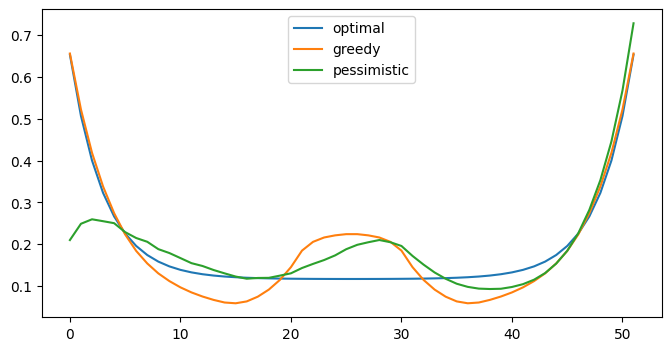

In [233]:
plt.figure(figsize=(8,4))

T = [k for k in range(len(u_optimal))]
plt.plot(T, u_optimal, label="optimal")

T = [k for k in range(len(u_greedy))]
plt.plot(T, u_greedy, label="greedy")

T = [k for k in range(len(u_pessimistic))]
plt.plot(T, u_pessimistic, label="pessimistic")

plt.legend()
plt.show()

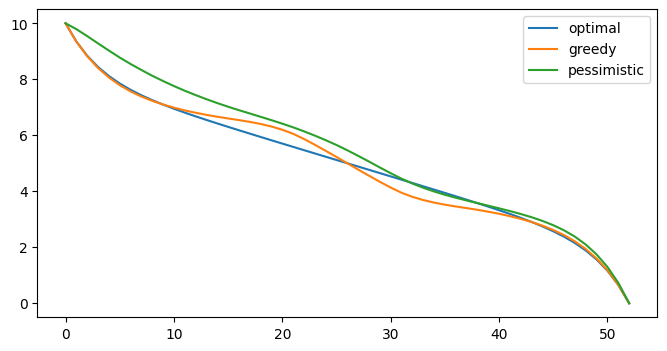

In [234]:
plt.figure(figsize=(8,4))

T = [k for k in range(len(inventory_optimal))]
plt.plot(T, inventory_optimal, label="optimal")

T = [k for k in range(len(inventory_greedy))]
plt.plot(T, inventory_greedy, label="greedy")

T = [k for k in range(len(inventory_pessimistic))]
plt.plot(T, inventory_pessimistic, label="pessimistic")

plt.legend()
plt.show()

In [235]:
def cost(u: list, G: list):
    """
    Compute execution cost J(u;G)
    """

    u = np.array(u, dtype=float)
    G = np.array(G, dtype=float)

    M = len(u)
    J = 0

    for i in range(M):
        for j in range(i + 1):
            J += G[i, j] * u[j] * u[i]

    return J

cost_optimal = cost(u_optimal, real_G)
cost_greedy = cost(u_greedy, real_G)
cost_pessimistic = cost(u_pessimistic, real_G)

results = pd.DataFrame({
    "strategy": ["optimal", "greedy", "pessimistic"],
    "cost": [cost_optimal, cost_greedy, cost_pessimistic]
})

print(results)

      strategy      cost
0      optimal  0.239302
1       greedy  0.241617
2  pessimistic  0.245089
